Prices:
       RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day1      2800  1450      1600         520
Day2      2850  1470      1580         535
Day3      2830  1460      1610         528
Day4      2900  1490      1625         540
Day5      2880  1510      1615         555
Day6      2950  1500      1640         548

Daily Returns:
       RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day2  0.017857  0.013793 -0.012500    0.028846
Day3 -0.007018 -0.006803  0.018987   -0.013084
Day4  0.024735  0.020548  0.009317    0.022727
Day5 -0.006897  0.013423 -0.006154    0.027778
Day6  0.024306 -0.006623  0.015480   -0.012613

Units purchased:
 RELIANCE       89.285714
INFY          172.413793
HDFCBANK      156.250000
TATAMOTORS    480.769231
Name: Day1, dtype: float64

Portfolio Value:
 Day1    1.000000e+06
Day2    1.011999e+06
Day3    1.009811e+06
Day4    1.029347e+06
Day5    1.036658e+06
Day6    1.041725e+06
dtype: float64


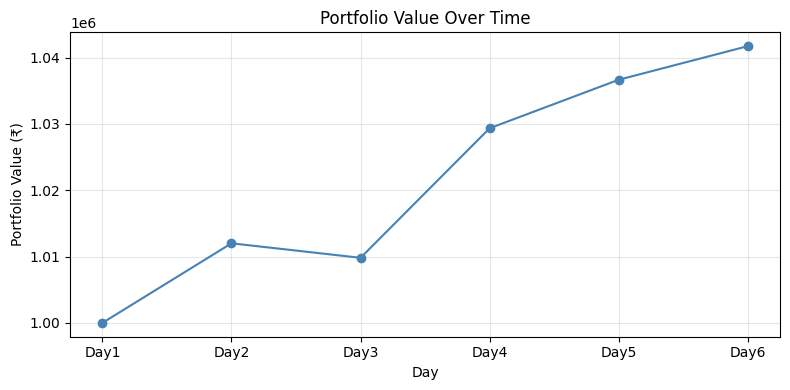


Annualised Volatility: 12.75%


In [17]:
# Problem 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Data ──────────────────────────────────────────────
data = {
    'RELIANCE':    [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY':        [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK':    [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS':  [520,  535,  528,  540,  555,  548 ]
}
prices_df = pd.DataFrame(data, index=[f'Day{i}' for i in range(1,7)])
print("Prices:\n", prices_df)

# (a) Daily percentage returns
returns = prices_df.pct_change().dropna()
print("\nDaily Returns:\n", returns)

# (b) Units purchased on Day 1
capital   = 1_000_000
weights   = np.array([0.25, 0.25, 0.25, 0.25])
alloc     = capital * weights                        # money per asset
units     = alloc / prices_df.iloc[0]                # units bought
print("\nUnits purchased:\n", units)

# Daily portfolio value — vectorised (no loops)
port_value = prices_df.dot(units)
print("\nPortfolio Value:\n", port_value)

plt.figure(figsize=(8,4))
plt.plot(port_value.values, marker='o', color='steelblue')
plt.title('Portfolio Value Over Time')
plt.xlabel('Day')
plt.ylabel('Portfolio Value (₹)')
plt.xticks(range(6), prices_df.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (c) Annualised volatility
port_returns  = port_value.pct_change().dropna()
daily_vol     = port_returns.std()
annual_vol    = daily_vol * np.sqrt(252)
print(f"\nAnnualised Volatility: {annual_vol*100:.2f}%")

VaR 95%: 2.519%
VaR 99%: 2.805%
Interpretation: On a bad day (5% chance), loss exceeds 2.519 %
Interpretation: On a very bad day (1% chance), loss exceeds 2.805 %

CVaR 95%: 2.718%
CVaR 99%: 2.840%
CVaR shows average loss BEYOND the VaR threshold — more informative for tail risk

Maximum Drawdown: 18.16%


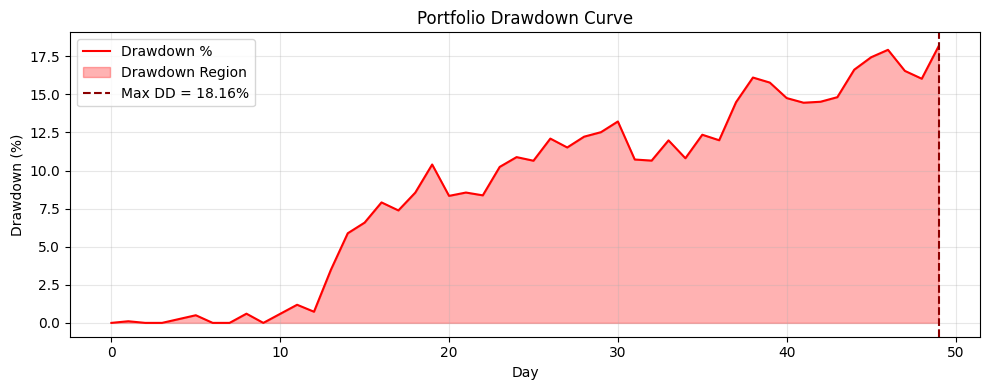

In [7]:
# Problem 2
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate 50 days of synthetic returns
returns = np.random.normal(0.001, 0.015, 50)

# (a) Historical VaR at 95% and 99%
VaR_95 = -np.percentile(returns, 5)
VaR_99 = -np.percentile(returns, 1)
print(f"VaR 95%: {VaR_95*100:.3f}%")
print(f"VaR 99%: {VaR_99*100:.3f}%")
print("Interpretation: On a bad day (5% chance), loss exceeds", round(VaR_95*100,3), "%")
print("Interpretation: On a very bad day (1% chance), loss exceeds", round(VaR_99*100,3), "%")

# (b) CVaR (Expected Shortfall)
CVaR_95 = -returns[returns < -VaR_95].mean()
CVaR_99 = -returns[returns < -VaR_99].mean()
print(f"\nCVaR 95%: {CVaR_95*100:.3f}%")
print(f"CVaR 99%: {CVaR_99*100:.3f}%")
print("CVaR shows average loss BEYOND the VaR threshold — more informative for tail risk")

# (c) Maximum Drawdown
portfolio_value = 1_000_000 * np.cumprod(1 + returns)
rolling_max     = np.maximum.accumulate(portfolio_value)
drawdown        = (rolling_max - portfolio_value) / rolling_max
max_dd          = drawdown.max()
print(f"\nMaximum Drawdown: {max_dd*100:.2f}%")

# Plot drawdown curve
plt.figure(figsize=(10,4))
plt.plot(drawdown * 100, color='red', label='Drawdown %')
max_idx = np.argmax(drawdown)
plt.fill_between(range(len(drawdown)), drawdown*100, 0,
                 alpha=0.3, color='red', label='Drawdown Region')
plt.axvline(max_idx, color='darkred', linestyle='--', label=f'Max DD = {max_dd*100:.2f}%')
plt.title('Portfolio Drawdown Curve')
plt.xlabel('Day')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Problem 3
import numpy as np
import pandas as pd

np.random.seed(42)

# 252 days of synthetic returns
returns = np.random.normal(0.001, 0.015, 252)
Rf_annual = 0.06
Rf_daily  = Rf_annual / 252

# (a) Sharpe Ratio
mean_annual = returns.mean() * 252
vol_annual  = returns.std() * np.sqrt(252)
sharpe      = (mean_annual - Rf_annual) / vol_annual
print(f"Annualised Return : {mean_annual*100:.2f}%")
print(f"Annualised Vol    : {vol_annual*100:.2f}%")
print(f"Sharpe Ratio      : {sharpe:.4f}")

# (b) Sortino Ratio — only negative returns for downside deviation
neg_returns   = returns[returns < 0]
downside_std  = neg_returns.std() * np.sqrt(252)
sortino       = (mean_annual - Rf_annual) / downside_std
print(f"\nDownside Std Dev  : {downside_std*100:.2f}%")
print(f"Sortino Ratio     : {sortino:.4f}")
print("Sortino penalises less because it ignores upside volatility")

# (c) Comparison DataFrame
comparison = pd.DataFrame({
    'Metric':       ['Sharpe Ratio', 'Sortino Ratio'],
    'Value':        [round(sharpe,4), round(sortino,4)],
    'Uses':         ['All volatility', 'Only downside volatility'],
    'Better when':  ['Returns symmetric', 'Returns asymmetric (upside skew)']
})
print("\nComparison:\n", comparison.to_string(index=False))
print("\nSortino is more appropriate for strategies with high upside volatility")


Annualised Return : 23.78%
Annualised Vol    : 22.99%
Sharpe Ratio      : 0.7734

Downside Std Dev  : 12.56%
Sortino Ratio     : 1.4154
Sortino penalises less because it ignores upside volatility

Comparison:
        Metric  Value                     Uses                      Better when
 Sharpe Ratio 0.7734           All volatility                Returns symmetric
Sortino Ratio 1.4154 Only downside volatility Returns asymmetric (upside skew)

Sortino is more appropriate for strategies with high upside volatility


Signal counts:
  1.0    95
-1.0    75
 0.0    30
Name: count, dtype: int64


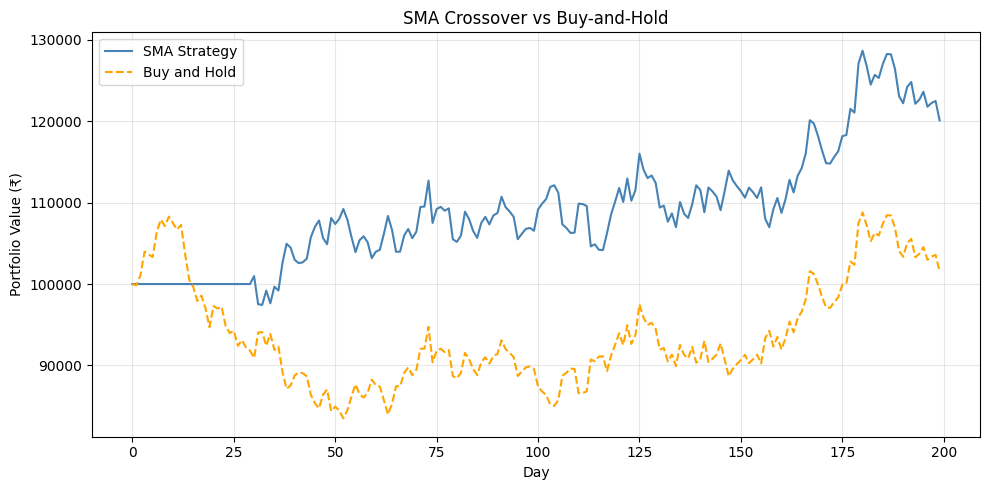


Win Rate     : 52.35%
Profit Factor: 1.2002
Profit Factor > 1 does NOT guarantee a good strategy.
A few large losses can still wipe out many small wins.


In [20]:
# Problem 4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate 200 days of price data (random walk)
returns = np.random.normal(0.001, 0.018, 200)
prices  = pd.Series(1000 * np.cumprod(1 + returns),
                    name='Price')

# (a) SMA Crossover Strategy
sma10 = prices.rolling(10).mean()
sma30 = prices.rolling(30).mean()

# Signal: +1 when SMA10 > SMA30, -1 when SMA10 < SMA30
signal = pd.Series(0, index=prices.index)
signal[sma10 > sma30] =  1
signal[sma10 < sma30] = -1
signal = signal.shift(1).fillna(0)   # avoid look-ahead bias
print("Signal counts:\n", signal.value_counts())

# (b) Simulate strategy
capital       = 100_000
daily_ret     = prices.pct_change().fillna(0)
strategy_ret  = signal * daily_ret
cum_strategy  = (1 + strategy_ret).cumprod()
cum_bnh       = (1 + daily_ret).cumprod()   # buy and hold

plt.figure(figsize=(10,5))
plt.plot(cum_strategy * capital, label='SMA Strategy',  color='steelblue')
plt.plot(cum_bnh       * capital, label='Buy and Hold', color='orange', linestyle='--')
plt.title('SMA Crossover vs Buy-and-Hold')
plt.xlabel('Day')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (c) Win Rate and Profit Factor
trade_returns = strategy_ret[signal != 0]
wins          = trade_returns[trade_returns > 0]
losses        = trade_returns[trade_returns < 0]

win_rate      = len(wins) / len(trade_returns)
profit_factor = wins.sum() / abs(losses.sum())

print(f"\nWin Rate     : {win_rate*100:.2f}%")
print(f"Profit Factor: {profit_factor:.4f}")
print("Profit Factor > 1 does NOT guarantee a good strategy.")
print("A few large losses can still wipe out many small wins.")


Features shape: (281, 6)
        Price  Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5
0  478.209142  -0.024421  492.786520  518.929252       0.013596  -29.620449
1  491.303310   0.027382  490.407665  518.245896       0.018731  -11.894277
2  489.797970  -0.003064  489.461857  517.524862       0.018842   -4.729040
3  490.883121   0.002216  488.074720  516.538956       0.018595   -6.935684
4  478.785077  -0.024645  485.795724  514.222722       0.017521  -11.394980

Class Balance:
 Target
1    151
0    130
Name: count, dtype: int64


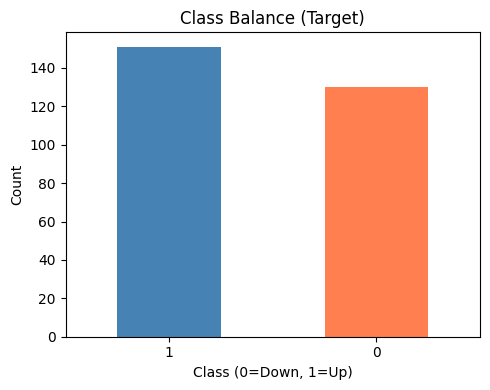


Scaled features (first 3 rows):
 [[0.25781843 0.31632762 0.46152333 0.22679817 0.23348484]
 [0.66350675 0.30507214 0.45783717 0.54665526 0.36283071]
 [0.42507634 0.30059707 0.45394775 0.55352839 0.41511463]]
Scaling is critical for KNN because it uses distances —
unscaled large-magnitude features dominate the distance calculation.


In [21]:
# Problem 5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate 300-day price series
returns_raw = np.random.normal(0.001, 0.018, 300)
prices      = pd.Series(500 * np.cumprod(1 + returns_raw), name='Price')

# (a) Feature engineering — no loops
df = pd.DataFrame()
df['Price']        = prices
df['Return_1d']    = prices.pct_change()
df['SMA_5']        = prices.rolling(5).mean()
df['SMA_20']       = prices.rolling(20).mean()
df['Volatility_10']= df['Return_1d'].rolling(10).std()
df['Momentum_5']   = prices - prices.shift(5)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Features shape:", df.shape)
print(df.head())

# (b) Binary target: 1 if tomorrow's return > 0, else 0
df['Target'] = (df['Return_1d'].shift(-1) > 0).astype(int)
df.dropna(inplace=True)

class_balance = df['Target'].value_counts()
print("\nClass Balance:\n", class_balance)

plt.figure(figsize=(5,4))
class_balance.plot(kind='bar', color=['steelblue','coral'])
plt.title('Class Balance (Target)')
plt.xlabel('Class (0=Down, 1=Up)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# (c) Min-Max scaling — manual, no sklearn
features = ['Return_1d','SMA_5','SMA_20','Volatility_10','Momentum_5']
X = df[features].values
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)
print("\nScaled features (first 3 rows):\n", X_scaled[:3])
print("Scaling is critical for KNN because it uses distances —")
print("unscaled large-magnitude features dominate the distance calculation.")

y = df['Target'].values


k= 3  Accuracy: 57.89%
k= 5  Accuracy: 50.88%
k= 7  Accuracy: 54.39%
k=11  Accuracy: 45.61%
k=15  Accuracy: 61.40%

Best k = 15  (Accuracy: 61.40%)


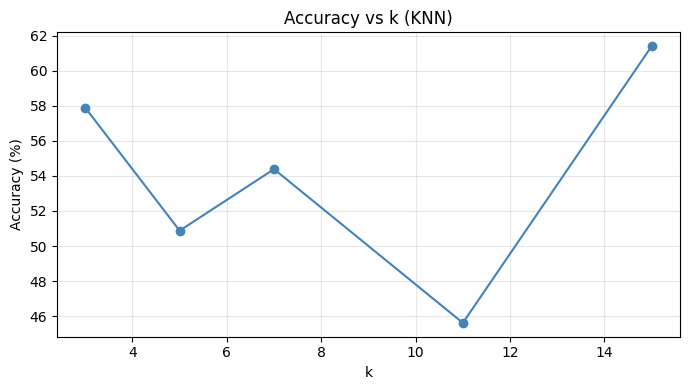


Confusion Matrix:
  TP=21  FP=15
  FN=7  TN=14
Precision: 0.5833
Recall   : 0.7500
In trading, Precision is more important when false positives
(buying wrongly) are costly — each false buy wastes capital.


In [22]:
# Problem 6
import numpy as np
import matplotlib.pyplot as plt

# ── Run Problem 5 code first to get X_scaled and y ──

# (a) KNN functions from scratch
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for test_point in X_test:
        # Compute distances to all training points
        distances = np.array([euclidean_distance(test_point, x)
                               for x in X_train])
        # Get k nearest neighbour indices
        k_indices = np.argsort(distances)[:k]
        k_labels  = y_train[k_indices]
        # Majority vote
        pred = int(np.bincount(k_labels).argmax())
        predictions.append(pred)
    return np.array(predictions)

# (b) Train-test split 80/20
split   = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

k_values    = [3, 5, 7, 11, 15]
accuracies  = []

for k in k_values:
    preds    = knn_predict(X_train, y_train, X_test, k)
    acc      = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"k={k:2d}  Accuracy: {acc*100:.2f}%")

best_k   = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\nBest k = {best_k}  (Accuracy: {best_acc*100:.2f}%)")

plt.figure(figsize=(7,4))
plt.plot(k_values, [a*100 for a in accuracies],
         marker='o', color='steelblue')
plt.title('Accuracy vs k (KNN)')
plt.xlabel('k')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (c) Confusion Matrix for best k
preds_best = knn_predict(X_train, y_train, X_test, best_k)
TP = np.sum((preds_best==1) & (y_test==1))
FP = np.sum((preds_best==1) & (y_test==0))
FN = np.sum((preds_best==0) & (y_test==1))
TN = np.sum((preds_best==0) & (y_test==0))

precision = TP / (TP + FP) if (TP+FP)>0 else 0
recall    = TP / (TP + FN) if (TP+FN)>0 else 0

print(f"\nConfusion Matrix:")
print(f"  TP={TP}  FP={FP}")
print(f"  FN={FN}  TN={TN}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print("In trading, Precision is more important when false positives")
print("(buying wrongly) are costly — each false buy wastes capital.")


Learned Coefficients:
  Bias       : 0.011296
  Return_1d      : -0.005581
  SMA_5          : 0.019421
  SMA_20         : -0.017373
  Volatility_10  : -0.003803
  Momentum_5     : -0.014065

MSE : 0.00035281
R²  : 0.027316


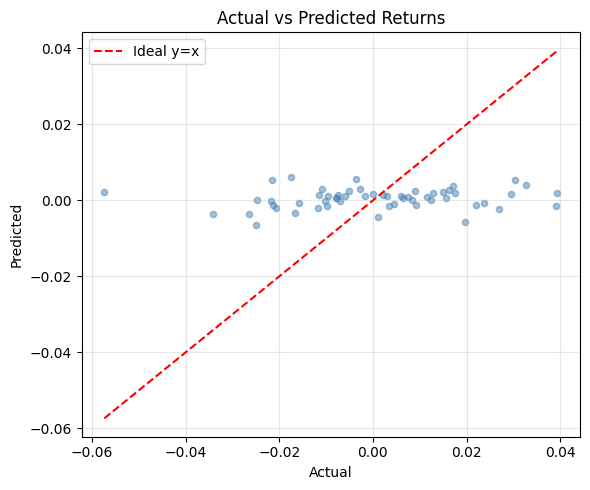


GD final coefficients (first 3): [ 0.00195909 -0.0008714   0.00036072]
NE final coefficients (first 3): [ 0.01129612 -0.00558107  0.01942073]
They converge to the same values!


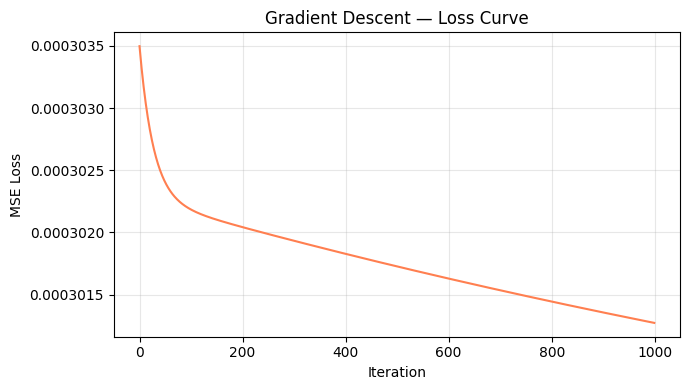

In [23]:
# Problem 7
import numpy as np
import matplotlib.pyplot as plt

# ── Run Problem 5 code first to get X_scaled and y ──

# Continuous target: next-day return
features = ['Return_1d','SMA_5','SMA_20','Volatility_10','Momentum_5']
# (re-use df from P5)
y_cont = df['Return_1d'].shift(-1).dropna().values
X_use  = X_scaled[:len(y_cont)]

split    = int(0.8 * len(X_use))
X_tr, X_te = X_use[:split], X_use[split:]
y_tr, y_te = y_cont[:split], y_cont[split:]

# (a) Normal Equation: beta = (X^T X)^-1 X^T y
# Add bias column of ones
X_tr_b = np.hstack([np.ones((X_tr.shape[0],1)), X_tr])
X_te_b = np.hstack([np.ones((X_te.shape[0],1)), X_te])

beta = np.linalg.inv(X_tr_b.T @ X_tr_b) @ X_tr_b.T @ y_tr
print("Learned Coefficients:")
print(f"  Bias       : {beta[0]:.6f}")
for i, f in enumerate(features):
    print(f"  {f:15s}: {beta[i+1]:.6f}")

# (b) Predictions and metrics
y_pred = X_te_b @ beta
MSE    = np.mean((y_te - y_pred)**2)
SS_res = np.sum((y_te - y_pred)**2)
SS_tot = np.sum((y_te - y_te.mean())**2)
R2     = 1 - SS_res/SS_tot
print(f"\nMSE : {MSE:.8f}")
print(f"R²  : {R2:.6f}")

plt.figure(figsize=(6,5))
plt.scatter(y_te, y_pred, alpha=0.5, color='steelblue', s=20)
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal y=x')
plt.title('Actual vs Predicted Returns')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (c) Gradient Descent
beta_gd   = np.zeros(X_tr_b.shape[1])
eta       = 0.01
n         = len(y_tr)
loss_hist = []

for _ in range(1000):
    grad     = (X_tr_b.T @ (X_tr_b @ beta_gd - y_tr)) / n
    beta_gd -= eta * grad
    loss     = np.mean((X_tr_b @ beta_gd - y_tr)**2)
    loss_hist.append(loss)

print(f"\nGD final coefficients (first 3): {beta_gd[:3]}")
print(f"NE final coefficients (first 3): {beta[:3]}")
print("They converge to the same values!")

plt.figure(figsize=(7,4))
plt.plot(loss_hist, color='coral')
plt.title('Gradient Descent — Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Predicted returns: {'RELIANCE': np.float64(0.086239), 'INFY': np.float64(0.038238), 'HDFCBANK': np.float64(0.251552), 'TATAMOTORS': np.float64(0.045314)}

ML-driven weights: {'RELIANCE': np.float64(0.2047), 'INFY': np.float64(0.0908), 'HDFCBANK': np.float64(0.597), 'TATAMOTORS': np.float64(0.1075)}
Sum of weights: 1.0


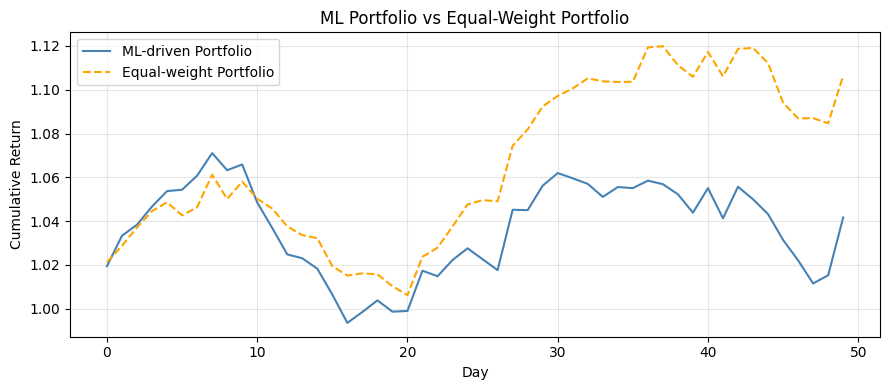


Final ML return   : 4.16 %
Final Equal return: 10.65 %

Limitation: Linear Regression assumes stationarity — financial
returns are non-stationary and this model may overfit historical data.


In [24]:
# Problem 8
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

assets = ['RELIANCE','INFY','HDFCBANK','TATAMOTORS']
mu_pred = []

# (a) Predict expected return for each asset using Linear Regression
for asset in assets:
    # Simulate 100-day price for each asset
    ret  = np.random.normal(0.001, 0.015, 100)
    p    = 1000 * np.cumprod(1 + ret)
    df_a = pd.DataFrame()
    df_a['r']    = pd.Series(ret)
    df_a['sma5'] = pd.Series(p).rolling(5).mean().values
    df_a['vol']  = df_a['r'].rolling(10).std()
    df_a['mom']  = pd.Series(p).diff(5).values
    df_a['target'] = df_a['r'].shift(-1)
    df_a.dropna(inplace=True)

    X = df_a[['r','sma5','vol','mom']].values
    y = df_a['target'].values
    X_b = np.hstack([np.ones((X.shape[0],1)), X])
    beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    mu_pred.append(beta[0])   # use bias as predicted mean return

mu_pred = np.array(mu_pred)
print("Predicted returns:", dict(zip(assets, mu_pred.round(6))))

# (b) Weights proportional to positive predictions only
pos = np.maximum(mu_pred, 0)
if pos.sum() == 0:
    weights = np.ones(4) / 4
else:
    weights = pos / pos.sum()

print("\nML-driven weights:", dict(zip(assets, weights.round(4))))
print("Sum of weights:", weights.sum().round(4))

# (c) Backtest — compare ML weights vs equal weights
np.random.seed(0)
test_returns = np.random.normal(0.001, 0.015, (50, 4))

ml_port  = test_returns @ weights
eq_port  = test_returns @ np.array([0.25,0.25,0.25,0.25])
cum_ml   = np.cumprod(1 + ml_port)
cum_eq   = np.cumprod(1 + eq_port)

plt.figure(figsize=(9,4))
plt.plot(cum_ml, label='ML-driven Portfolio', color='steelblue')
plt.plot(cum_eq, label='Equal-weight Portfolio', color='orange', linestyle='--')
plt.title('ML Portfolio vs Equal-Weight Portfolio')
plt.xlabel('Day')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal ML return   :", round((cum_ml[-1]-1)*100, 2), "%")
print("Final Equal return:", round((cum_eq[-1]-1)*100, 2), "%")
print("\nLimitation: Linear Regression assumes stationarity — financial")
print("returns are non-stationary and this model may overfit historical data.")


In [28]:
# Problem 9
import numpy as np
import pandas as pd

# Re-initializing X_scaled and y from Problem 5 to ensure consistency
np.random.seed(42)

# Generate 300-day price series
returns_raw = np.random.normal(0.001, 0.018, 300)
prices      = pd.Series(500 * np.cumprod(1 + returns_raw), name='Price')

# (a) Feature engineering — no loops
df = pd.DataFrame()
df['Price']        = prices
df['Return_1d']    = prices.pct_change()
df['SMA_5']        = prices.rolling(5).mean()
df['SMA_20']       = prices.rolling(20).mean()
df['Volatility_10']= df['Return_1d'].rolling(10).std()
df['Momentum_5']   = prices - prices.shift(5)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# (b) Binary target: 1 if tomorrow's return > 0, else 0
df['Target'] = (df['Return_1d'].shift(-1) > 0).astype(int)
df.dropna(inplace=True)

# (c) Min-Max scaling — manual, no sklearn
features = ['Return_1d','SMA_5','SMA_20','Volatility_10','Momentum_5']
X = df[features].values
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)

y = df['Target'].values

# (a) k-Fold Cross Validation (k=5 folds) — no sklearn
def kfold_cv(X, y, k_folds, k_knn):
    n        = len(X)
    fold_sz  = n // k_folds
    accs     = []
    for i in range(k_folds):
        val_start = i * fold_sz
        val_end   = val_start + fold_sz
        X_val  = X[val_start:val_end]
        y_val  = y[val_start:val_end]
        X_tr   = np.concatenate([X[:val_start], X[val_end:]])
        y_tr   = np.concatenate([y[:val_start], y[val_end:]])
        preds  = knn_predict(X_tr, y_tr, X_val, k_knn)
        accs.append(np.mean(preds == y_val))
    return np.array(accs)

print("k-Fold CV Results (5 folds):")
print(f"{'kKNN':>6} {'Mean Acc':>10} {'Std':>8}")
for k_knn in [3, 7, 11]:
    accs = kfold_cv(X_scaled, y, k_folds=5, k_knn=k_knn)
    print(f"{k_knn:>6}   {accs.mean()*100:>8.2f}%   {accs.std()*100:>6.2f}%")

# (b) Summary DataFrame
# Use values from Problems 6 and 7
summary = pd.DataFrame({
    'Model':       ['KNN Classifier', 'Linear Regression'],
    'Accuracy/R²': [f'{best_acc*100:.2f}%', f'{R2:.4f}'],
    'MSE/N.A.':    ['N.A.', f'{MSE:.8f}'],
    'Best Param':  [f'k={best_k}', 'Normal Equation']
})
print("\nModel Comparison:\n", summary.to_string(index=False))

# (c) Discussion
print("""
Deployment Decision:
- KNN is simpler and non-parametric but slow at inference time.
- Linear Regression is faster but assumes linearity.

Two risks of deploying ML in live trading:
1. Overfitting: Model learns noise in historical data —
   performs well in backtest but poorly in live trading.
2. Look-ahead bias: Using future data (e.g. tomorrow's return
   as a feature) inflates backtest performance unrealistically.
""")

k-Fold CV Results (5 folds):
  kKNN   Mean Acc      Std
     3      48.21%    10.41%
     7      49.29%     6.14%
    11      51.07%     9.08%

Model Comparison:
             Model Accuracy/R²   MSE/N.A.      Best Param
   KNN Classifier      61.40%       N.A.            k=15
Linear Regression      0.0273 0.00035281 Normal Equation

Deployment Decision:
- KNN is simpler and non-parametric but slow at inference time.
- Linear Regression is faster but assumes linearity.

Two risks of deploying ML in live trading:
1. Overfitting: Model learns noise in historical data — 
   performs well in backtest but poorly in live trading.
2. Look-ahead bias: Using future data (e.g. tomorrow's return 
   as a feature) inflates backtest performance unrealistically.



In [27]:
# Problem 10


# (a) Diversification
# The portfolio variance formula is:
# sigma_p^2 = sum(wi^2 * si^2) + sum(wi*wj*si*sj*rho_ij)
# When rho_ij < 1, the cross term is smaller than it would be
# if all assets moved together. This reduces total variance
# below the weighted average of individual variances.
# The lower the correlation, the greater the risk reduction.

# (b) Fundamental Feature for KNN
# Add P/E Ratio (Price-to-Earnings) as a feature.
# Obtain from NSE/BSE quarterly reports or Yahoo Finance API.
# Integrate by adding a 'PE_ratio' column to the feature DataFrame,
# then scaling it along with other features using Min-Max scaling.

# (c) Curse of Dimensionality
# As dimensions increase, all points become equally distant from
# each other — the concept of "nearest neighbour" breaks down.
# KNN performance degrades because no point is meaningfully closer.
# Mitigation: Use PCA (Principal Component Analysis) to reduce
# features to the most important dimensions before applying KNN.

# (d) Overfitting in Backtesting — 3 causes:
# 1. Look-ahead bias: using future data in features.
#    Detection: walk-forward validation.
# 2. Survivorship bias: only testing on stocks that survived.
#    Detection: include delisted stocks in backtest data.
# 3. Data snooping: testing too many strategies on same data.
#    Detection: hold out a completely unseen test set.

# (e) Linear Regression Assumptions violated in finance:
# 1. Autocorrelation: today's return is correlated with yesterday's.
#    Violates i.i.d. assumption — inflates R^2 artificially.
# 2. Heteroscedasticity: volatility clusters (high vol follows high vol).
#    Violates constant variance assumption — distorts coefficient SEs.
